In [ ]:
for ep in tqdm(range(epoch), desc="Epochs", position=0):
    pbar = tqdm(train_dataloader, desc=f"ep {ep+1}/{epoch}", leave=False, position=1)
    for step, batch in enumerate(pbar):
        optimizer.zero_grad(set_to_none=zero_to_none)

        x_1, c = batch
        c_onehot = torch.nn.functional.one_hot(c, num_classes=10).float()
        c_onehot = c_onehot.to(device, non_blocking=True)

        x_1 = x_1.to(device, non_blocking=True).reshape(x_1.shape[0], *data_shape)
        x_0 = torch.randn_like(x_1)
        t = rf_train.sample_train_time(x_1.shape[0]).to(device, non_blocking=True)

        # --- forward (bf16 autocast) ---
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            x_t, dot_x_t = rf_train.get_interpolation(x_0=x_0, x_1=x_1, t=t)
            v_pred = rf_train.get_velocity(x_t, t, class_labels=c_onehot)

        # --- pure MSE loss in fp32 for stability ---
        loss = torch.nn.functional.mse_loss(v_pred.float(), dot_x_t.float())
        mse_loss = float(loss.detach().item())

        loss.backward()

        if grad_clip_norm is not None:
            torch.nn.utils.clip_grad_norm_(rf_train.parameters(), grad_clip_norm)

        optimizer.step()

        global_step += 1
        cur_nimg += x_1.shape[0]
        ema_flow.update(cur_nimg=cur_nimg, batch_size=x_1.shape[0])

        loss_val = float(loss.detach().item())
        running_loss = loss_val if running_loss is None else (
            smooth_alpha * running_loss + (1 - smooth_alpha) * mse_loss
        )

        pbar.set_postfix({
            "mse_loss": f"{mse_loss:.4f}",
            "mse_loss_ema": f"{running_loss:.4f}",
            "steps": global_step
        })

    safe_tqdm_write(
        f"[epoch {ep+1}/{epoch}] steps={global_step:,} "
        f"mse_loss={mse_loss:.4f}, mse_loss_ema={running_loss:.4f}"
    )

    if ep % 10 == 0:
        flow_model.save_pretrained(f"./checkpoints/flow_mnist_unet_conditionalaa")
        ema_flow.save_pretrained(f"./checkpoints/flow_mnist_unet_conditionalaa")

print(f"Training done. Total steps: {global_step:,}, last loss: {loss_val:.4f}, EMA: {running_loss:.4f}")

Epochs:   0%|          | 0/200 [00:00<?, ?it/s]

ep 1/200:   0%|          | 0/118 [00:00<?, ?it/s]

[epoch 1/200] steps=118 mse_loss=0.2293, mse_loss_ema=0.8432
Configuration saved to ./checkpoints/flow_mnist_unet_conditionalaa/unet_config.json
Model weights saved to ./checkpoints/flow_mnist_unet_conditionalaa/unet_model.pt
EMA model weights saved to ./checkpoints/flow_mnist_unet_conditionalaa/unet_ema.pt


ep 2/200:   0%|          | 0/118 [00:00<?, ?it/s]

[epoch 2/200] steps=236 mse_loss=0.2156, mse_loss_ema=0.4069


...

[epoch 198/200] steps=23,364 mse_loss=0.1700, mse_loss_ema=0.1620


ep 199/200:   0%|          | 0/118 [00:00<?, ?it/s]

[epoch 199/200] steps=23,482 mse_loss=0.1893, mse_loss_ema=0.1623


ep 200/200:   0%|          | 0/118 [00:00<?, ?it/s]

[epoch 200/200] steps=23,600 mse_loss=0.1654, mse_loss_ema=0.1621
Training done. Total steps: 23,600, last loss: 0.1654, EMA: 0.1621


### Class Conditional Generation without CFG

In [ ]:
from rectified_flow.samplers import EulerSampler, SDESampler

# flow_model = SongUNet.from_pretrained(f"./checkpoints/flow_mnist_unet_conditional", use_ema=False).to(device)

model_inference = flow_model.eval()

rf_inference = RectifiedFlow(
    data_shape=data_shape,
    velocity_field=model_inference,
    device=device,
)

# generate 100 samples for each class
class_labels = torch.arange(10, device=device)
class_labels = class_labels.repeat_interleave(10, dim=0)
class_onehot = torch.nn.functional.one_hot(class_labels, num_classes=10).float()

euler_sampler = EulerSampler(rf_inference, num_steps=50, num_samples=100)
sde_sampler = SDESampler(rf_inference, num_steps=50, noise_scale=50, noise_decay_rate=0., num_samples=100)

In [ ]:
x_1_euler = euler_sampler.sample_loop(seed=33, class_labels=class_onehot).trajectories[-1]
x_1_sde = sde_sampler.sample_loop(seed=33, class_labels=class_onehot).trajectories[-1]

print(x_1_euler.shape)  # torch.Size([20, 1, 28, 28])

torch.Size([100, 1, 28, 28])


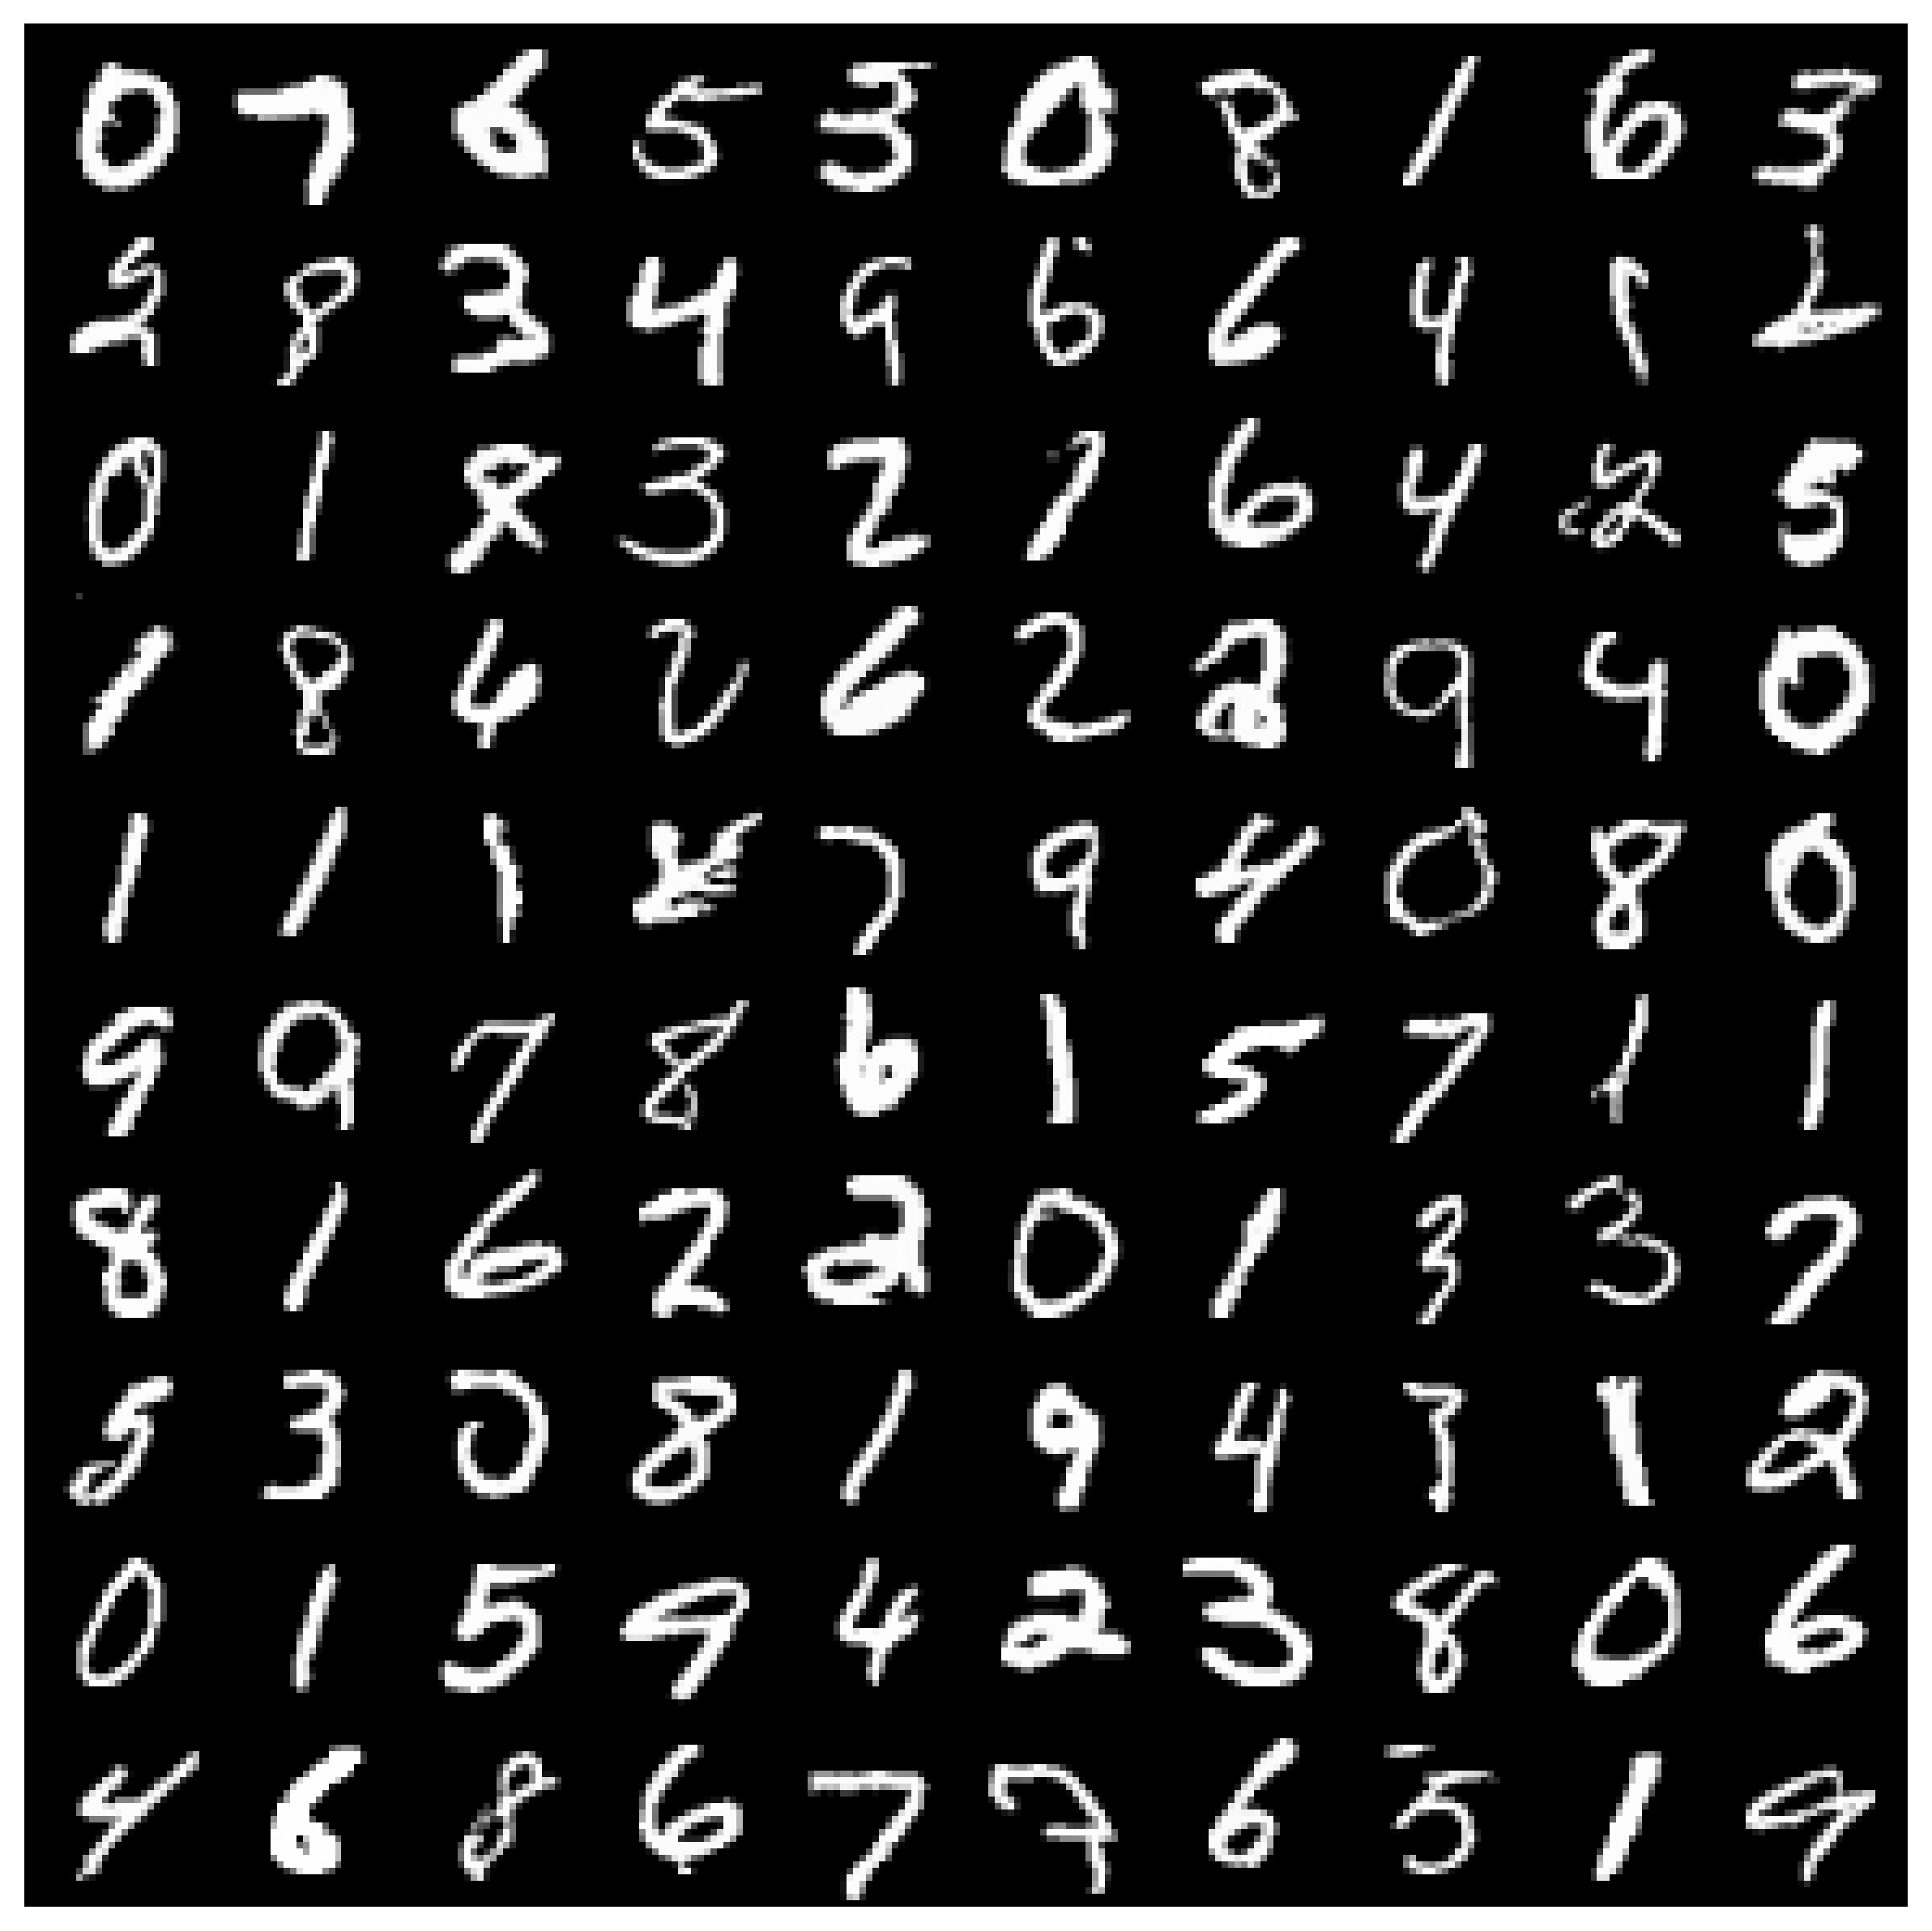

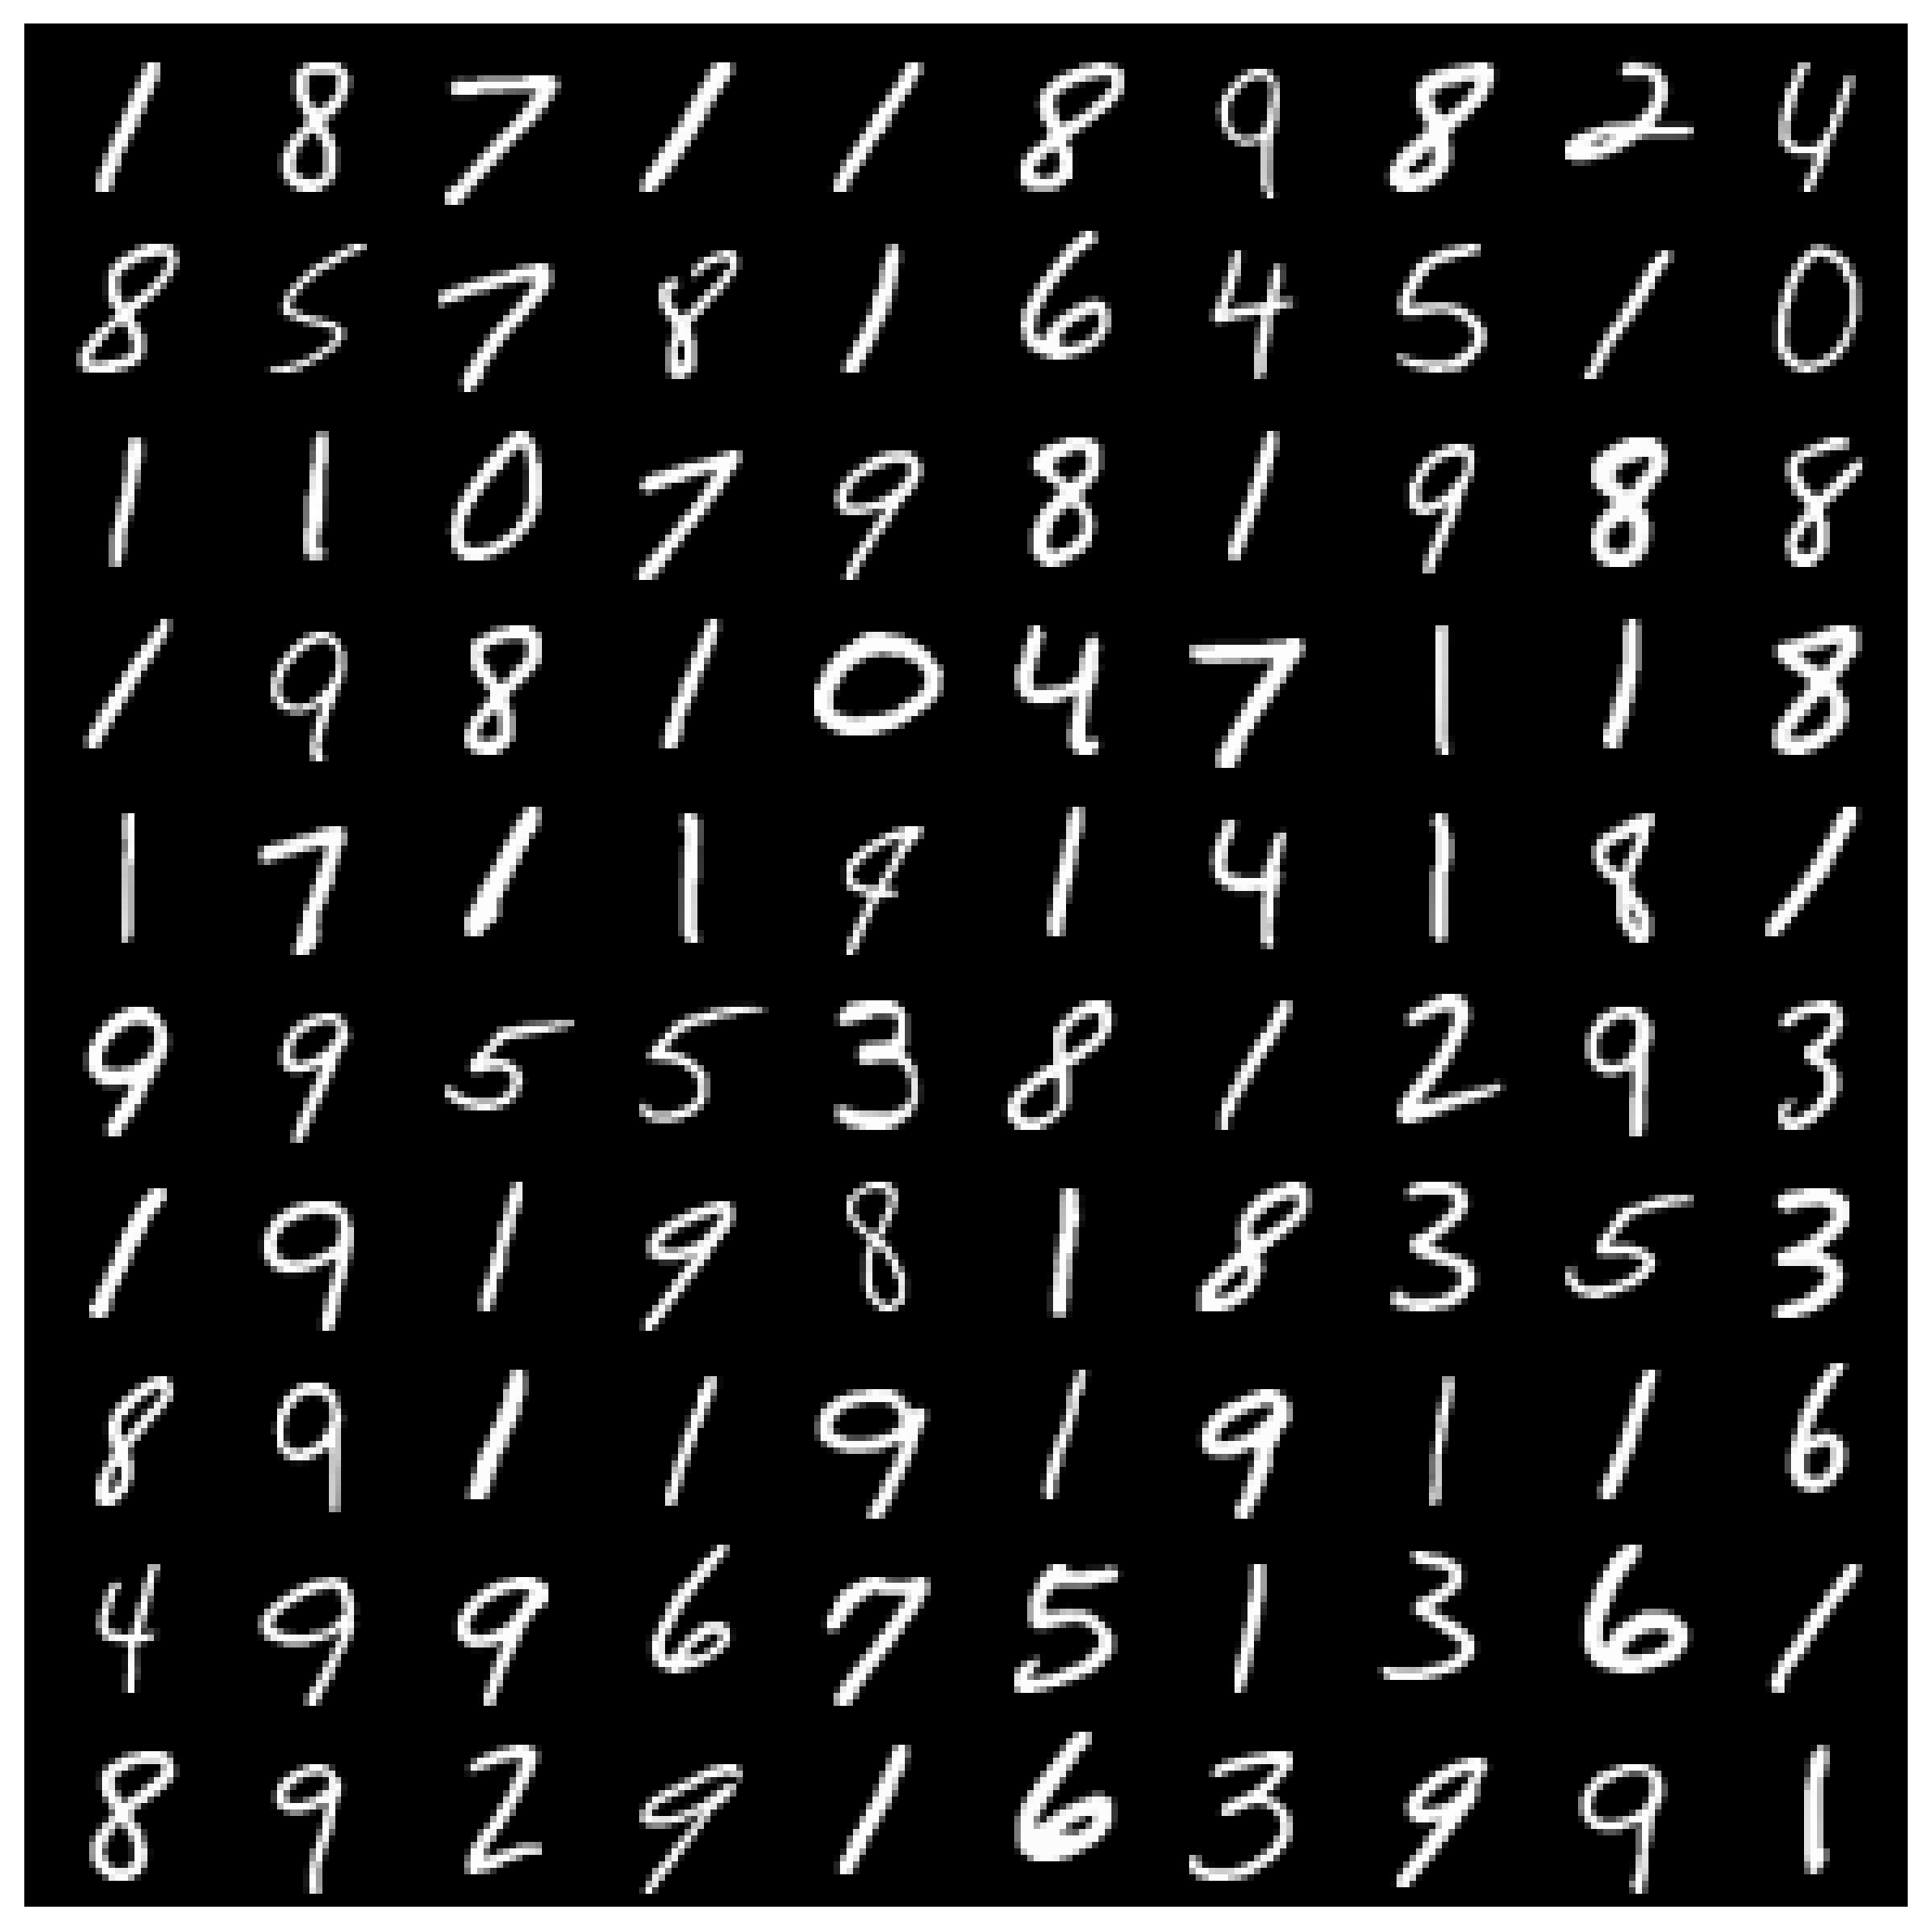

In [ ]:
from rectified_flow.utils import plot_cifar_results

plot_cifar_results(x_1_euler)
plot_cifar_results(x_1_sde)

### Class Conditional Generation with CFG

In [ ]:
from rectified_flow.samplers import EulerSampler, SDESampler

flow_model = SongUNet.from_pretrained(f"/content/rectified-flow/checkpoints/flow_mnist_unet_conditionalaa", use_ema=True).to(device)

model_inference = flow_model.eval()

def velocity_with_cfg(x, t, class_labels=None, cfg_scale=3.5):
    assert class_labels is not None
    v_uncond = model_inference(x, t, torch.zeros_like(class_labels))
    v_cond = model_inference(x, t, class_labels)
    return cfg_scale * v_cond + (1. - cfg_scale) * v_uncond

rf_inference = RectifiedFlow(
    data_shape=data_shape,
    velocity_field=velocity_with_cfg,
    device=device,
)

# generate 100 samples for each class
class_labels = torch.arange(10, device=device)
class_labels = class_labels.repeat_interleave(10, dim=0)
class_onehot = torch.nn.functional.one_hot(class_labels, num_classes=10).float()

euler_sampler = EulerSampler(rf_inference, num_steps=50, num_samples=100)
sde_sampler = SDESampler(rf_inference, num_steps=50, noise_scale=5, noise_decay_rate=0., num_samples=100)

Model loaded from /content/rectified-flow/checkpoints/flow_mnist_unet_conditionalaa/unet_ema.pt


In [ ]:
x_1_euler = euler_sampler.sample_loop(seed=33, class_labels=class_onehot).trajectories[-1]
x_1_sde = sde_sampler.sample_loop(seed=33, class_labels=class_onehot).trajectories[-1]

print(x_1_euler.shape)  # torch.Size([20, 1, 28, 28])

torch.Size([100, 1, 28, 28])


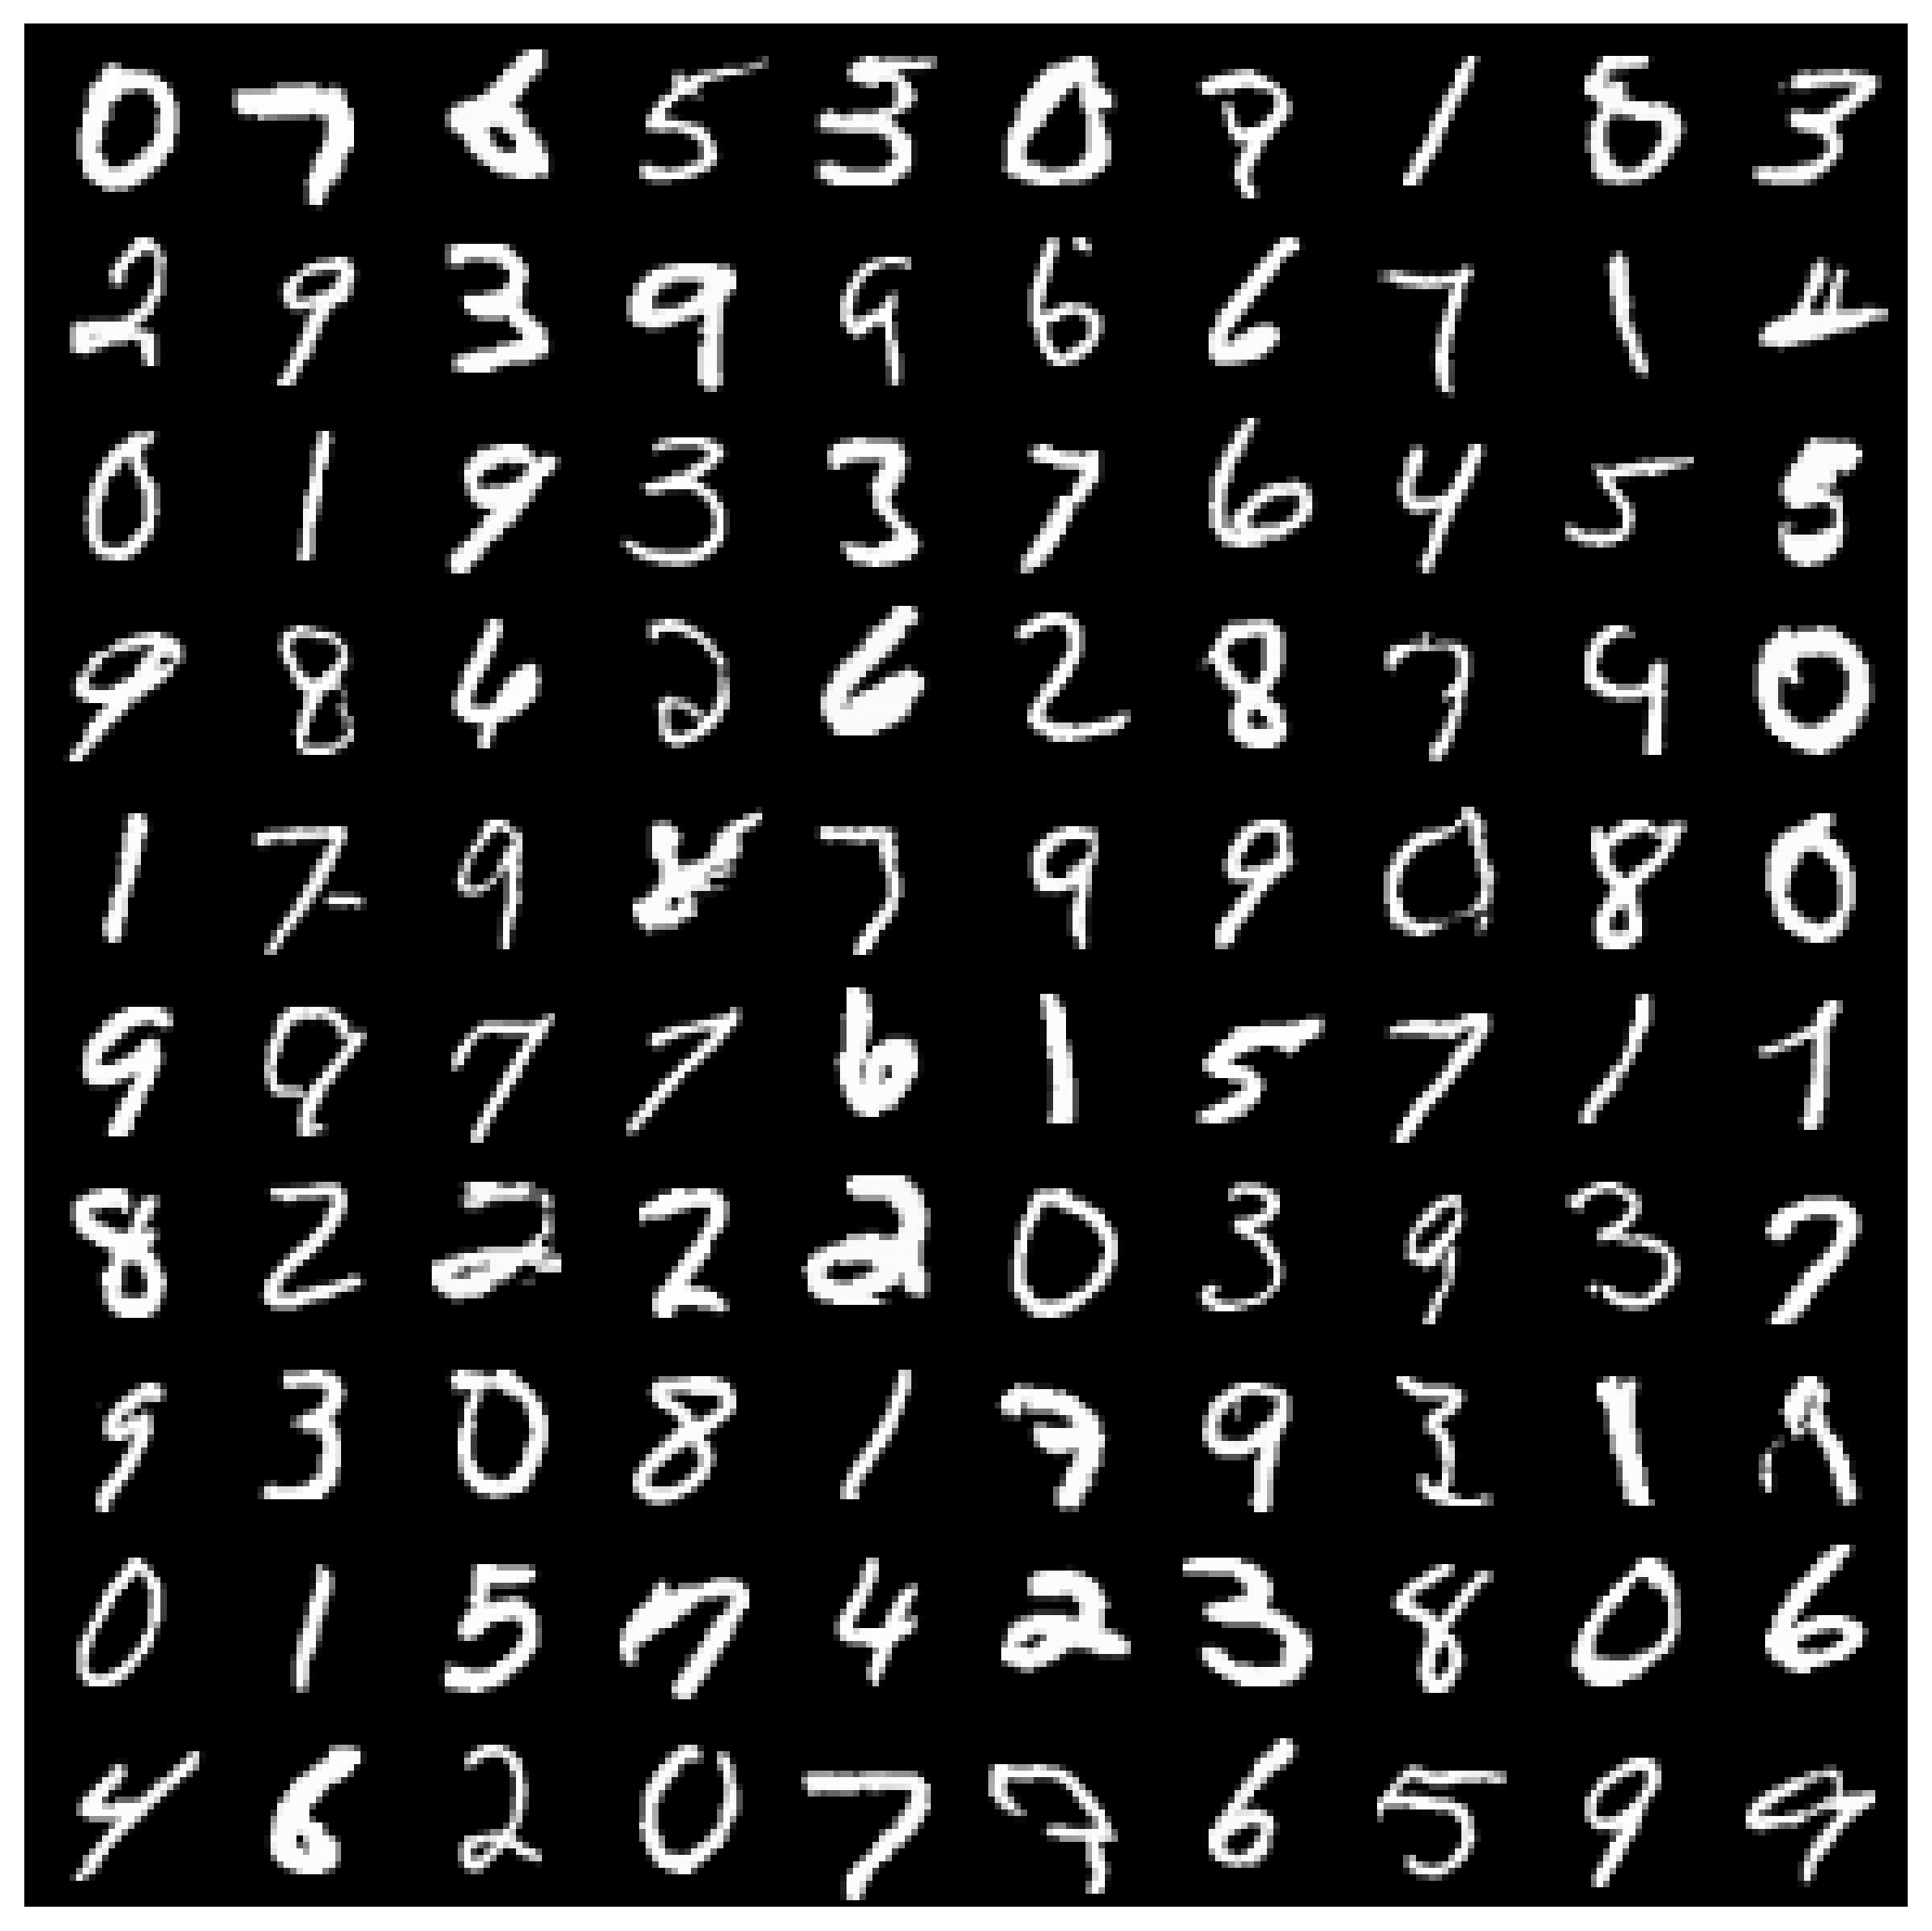

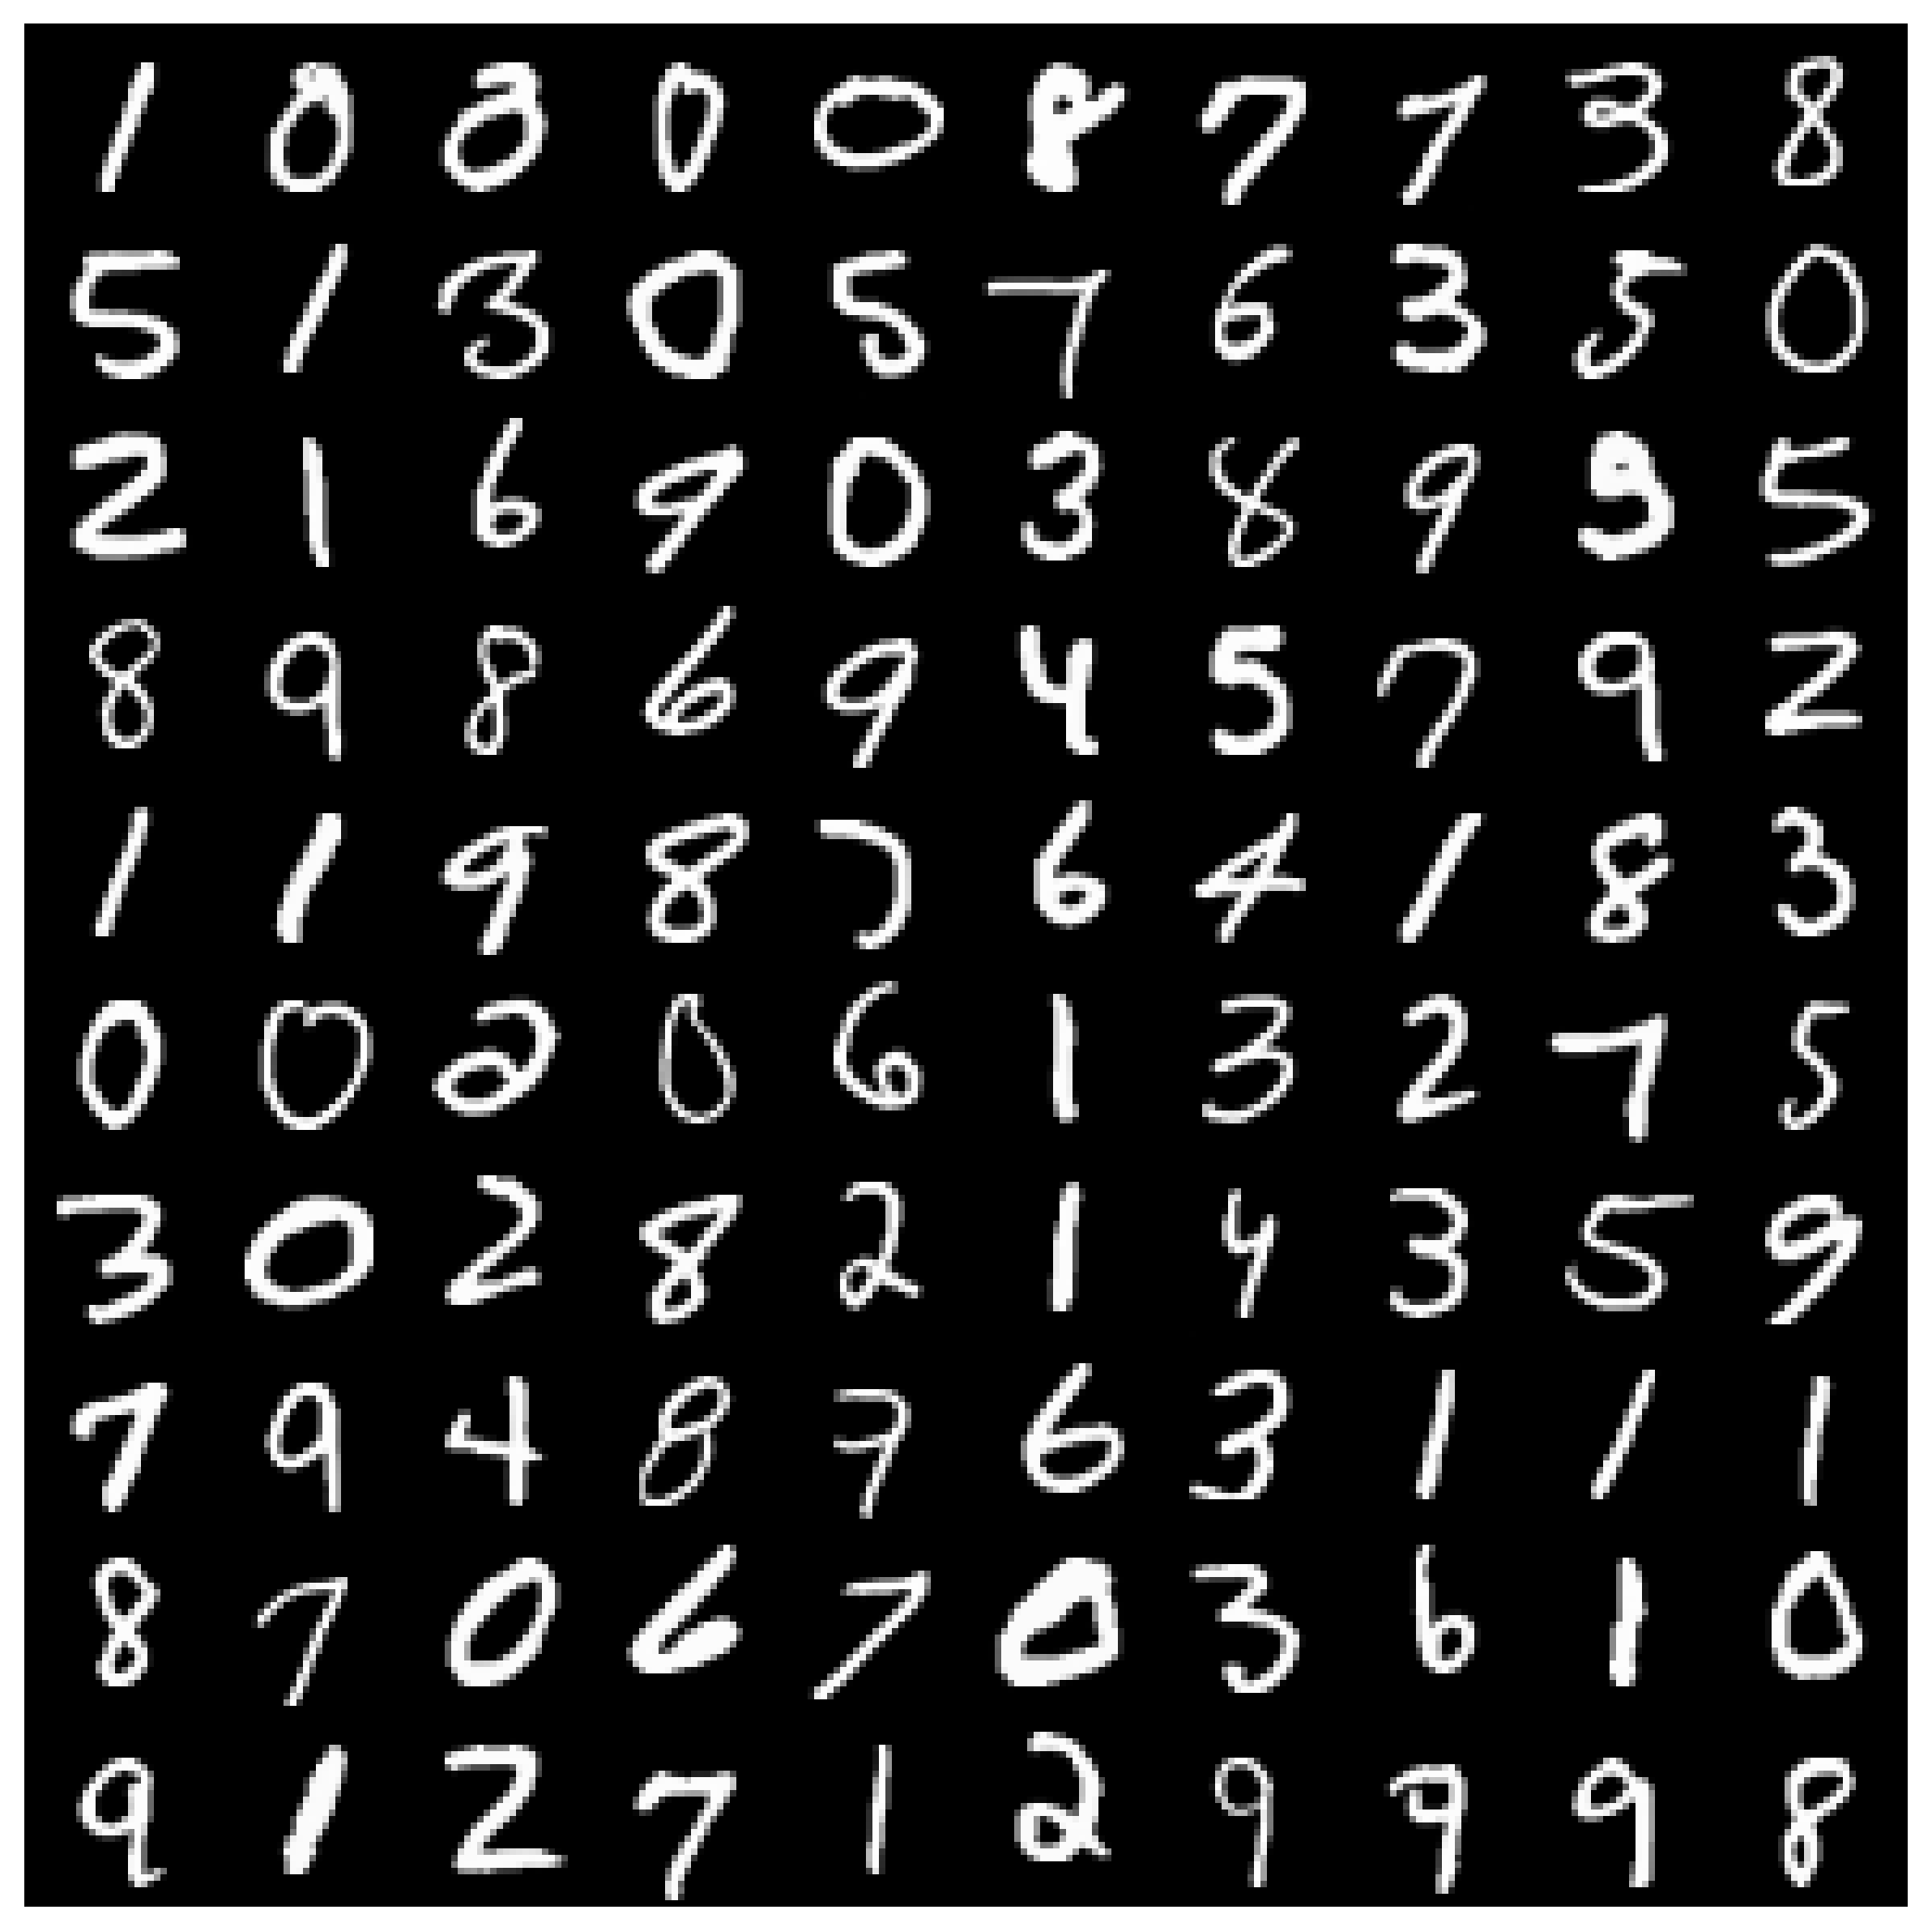

In [ ]:
from rectified_flow.utils import plot_cifar_results

plot_cifar_results(x_1_euler)
plot_cifar_results(x_1_sde)

## Part 3 - Conditional Generation and Classifier-Free Guidance

These cells streamline conditional sampling along with a Classifier-Free Guidance (CFG) sweep. Provide a conditional Rectified Flow model (either the one trained above or a checkpoint) and toggle the flags to generate digits for different CFG scales.

In [ ]:
from rectified_flow.samplers import EulerSampler

# Plug in the conditional flow model you want to evaluate.
# By default we reuse `flow_model`, but you can load EMA weights or another checkpoint here.
conditional_flow_model = flow_model.eval()

rf_conditional = RectifiedFlow(
    data_shape=data_shape,
    velocity_field=conditional_flow_model,
    device=device,
)

samples_per_class = 10
cond_sampling_steps = 50
classes = torch.arange(10, device=device).repeat_interleave(samples_per_class)
class_onehot = torch.nn.functional.one_hot(classes, num_classes=10).float()

run_conditional_sampling = False
conditional_samples = None


def sample_conditional_digits(num_steps, *, seed=0):
    torch.manual_seed(seed)
    x0 = torch.randn(class_onehot.shape[0], *data_shape, device=device)
    sampler = EulerSampler(rf_conditional, num_steps=num_steps)
    with torch.inference_mode():
        traj = sampler.sample_loop(x_0=x0, class_labels=class_onehot).trajectories[-1]
    return traj.detach().cpu()


if run_conditional_sampling:
    conditional_samples = sample_conditional_digits(cond_sampling_steps)
    plot_cifar_results(conditional_samples, title=f'Conditional samples ({cond_sampling_steps} steps)')


In [ ]:
class CFGVelocityWrapper(torch.nn.Module):
    def __init__(self, base_model, scale):
        super().__init__()
        self.base_model = base_model
        self.scale = scale

    def forward(self, x, t, class_labels=None):
        if class_labels is None:
            raise ValueError('CFG requires class labels for conditioning.')
        null_labels = torch.zeros_like(class_labels)
        v_uncond = self.base_model(x, t, null_labels)
        v_cond = self.base_model(x, t, class_labels)
        return v_uncond + self.scale * (v_cond - v_uncond)


cfg_scales = [0.0, 0.5, 1.0, 2.0, 3.0]
cfg_sampling_steps = 50
run_cfg_sweep = False
cfg_results = {}


def run_cfg_sampling(scales, *, seed=0):
    torch.manual_seed(seed)
    x0 = torch.randn(class_onehot.shape[0], *data_shape, device=device)
    results = {}

    for scale in scales:
        cfg_velocity = CFGVelocityWrapper(conditional_flow_model, scale)
        rf_cfg = RectifiedFlow(
            data_shape=data_shape,
            velocity_field=cfg_velocity,
            device=device,
        )
        sampler = EulerSampler(rf_cfg, num_steps=cfg_sampling_steps)
        with torch.inference_mode():
            traj = sampler.sample_loop(x_0=x0, class_labels=class_onehot).trajectories[-1]
        samples_cpu = traj.detach().cpu()
        results[scale] = samples_cpu
        print(f"[cfg] scale={scale:.1f} | mean={samples_cpu.mean():.4f} | std={samples_cpu.std():.4f}")

    return results


if run_cfg_sweep:
    cfg_results = run_cfg_sampling(cfg_scales)


In [ ]:
def visualize_cfg_results(results, max_examples=64):
    if not results:
        print('No CFG runs recorded yet.')
        return

    for scale, samples in results.items():
        title = f'CFG scale {scale:.1f}'
        plot_cifar_results(samples[:max_examples], title=title)


visualize_cfg_results(cfg_results)


No CFG runs recorded yet.


### Part 16.3 – Conditional generation and Classifier-Free Guidance (CFG)

In the conditional setup, the model predicts a velocity field that depends on
both the image `x` and the class label `y`. For classifier-free guidance, we
run the model twice:

- once **without** a label (unconditional): \( v(x, \varnothing) \)
- once **with** the desired class label: \( v(x, y) \)

The guided velocity is then defined as

\[
v_t^{\mathrm{CFG}}(x) \;=\; v(x, \varnothing) \;+\; s \, \big( v(x, y) - v(x, \varnothing) \big),
\]

where \( s \) is the guidance scale.

**Intuition:**  
- \( v(x, \varnothing) \) encourages general realism.  
- \( v(x, y) - v(x, \varnothing) \) measures how much the class label changes
  the prediction. Scaling this difference by \( s \) strengthens or weakens
  the conditioning signal.

We experimented with several CFG scales (e.g., \( s \in \{0.0, 0.5, 1.0, 2.0, 3.0\} \):

- **\( s = 0.0 \)** (purely unconditional):  
  - Samples are diverse but not strongly tied to any specific digit class.

- **Small to moderate \( s \) (0.5–2.0)**:  
  - Digits become **sharper** and more clearly match the target class label.  
  - Diversity is still fairly high, and results look visually best in this range.

- **Large \( s \) (around 3.0 or higher)**:  
  - The digits are very **class-consistent and sharp**, but sometimes show
    minor artifacts or reduced diversity (some classes start to look repetitive).

In summary, CFG modifies the velocity prediction by pushing the model in the
direction of the class-conditioned velocity \( v(x, y) \) while keeping the
unconditional velocity as a baseline. Moderate guidance scales provide a good
balance between sample quality, class control, and diversity.
